### Particle Filter Test

In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from typing import Protocol, Optional, Any, runtime_checkable
from functools import partial

## UNDER CONSTRUCTION
from autoforge.managers import ParticleFilter
from autoforge.components.FilterPredictors import PFPredictor
from autoforge.components.FilterCorrectors import PFCorrector
from autoforge.components.DynamicsModels import Unicycle
from autoforge.components.ObservationModels import RangeOnlyTrilateration
from autoforge.components.ProbabilityModels import MultivariateGuassianPDF


ModuleNotFoundError: No module named 'autoforge'

Running filters...
Saving GIF...
Done.


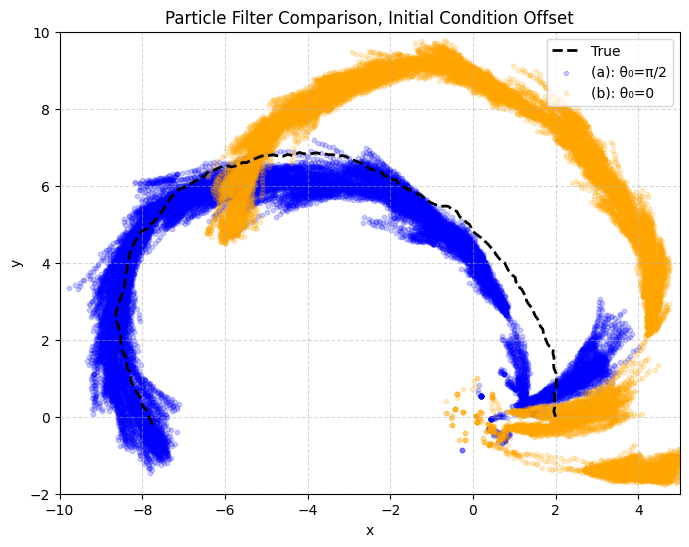

In [ ]:
# Test generated via LLM

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

x_true = jnp.array(np.loadtxt("HW6-X.txt"))
y_meas = jnp.array(np.loadtxt("HW6-Y.txt"))

T = y_meas.shape[0]

dt = 1.0
u = 0.1
omega = 0.02

process_std = 0.03
measurement_std = 0.5
measurement_cov = (measurement_std ** 2) * jnp.eye(2)

def run_case(init_mean, init_cov, n_particles):

    key = jax.random.PRNGKey(0)

    pf = ParticleFilter(
        predictor=PFPredictor(),
        corrector=PFCorrector(),
        likelihood=MultivariateGuassianPDF(),
        init_mean=jnp.array(init_mean),
        init_cov=jnp.array(init_cov),
        n_particles=n_particles,
        standard_dev=process_std,
        measurement_cov=measurement_cov,
        observation_model=RangeOnlyTrilateration(),
        dynamics=Unicycle(),
        key=key,
        Neff_threshold=n_particles / 2
    )

    estimates = []
    particles_history = []

    for t in range(T):
        control = jnp.array([u, omega])
        measurement = y_meas[t]

        est = pf.estimate(control, measurement, dt)

        estimates.append(est)
        particles_history.append(pf._particles)

    return jnp.stack(estimates), jnp.stack(particles_history)


print("Running filters...")

est_a, particles_a = run_case([2.0, 0.0, jnp.pi/2], jnp.eye(3), 100)
est_b, particles_b = run_case([0.0, 0.0, 0.0], jnp.eye(3), 100)

min_len = min(len(est_a), len(est_b), len(x_true))

est_a = est_a[:min_len]
est_b = est_b[:min_len]
particles_a = particles_a[:min_len]
particles_b = particles_b[:min_len]
x_plot = x_true[:min_len]

plt.style.use("default")

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_xlim(-10, 5)
ax.set_ylim(-2, 10)

ax.set_title("Particle Filter Comparison, Initial Condition Offset")
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.grid(True, linestyle="--", alpha=0.5)

true_line, = ax.plot([], [], 'k--', linewidth=2, label="True")

scatter_a = ax.scatter([], [], s=10, color='blue', alpha=0.2,
                       label="(a): θ₀=π/2")
scatter_b = ax.scatter([], [], s=10, color='orange', alpha=0.2,
                       label="(b): θ₀=0")

ax.legend(loc="upper right")

def update(frame):

    if frame == 0:
        return true_line, scatter_a, scatter_b

    # true trajectory
    true_line.set_data(x_plot[:frame, 0], x_plot[:frame, 1])

    pa = particles_a[:frame].reshape(-1, particles_a.shape[-1])
    pb = particles_b[:frame].reshape(-1, particles_b.shape[-1])

    scatter_a.set_offsets(np.array(pa[:, :2]))
    scatter_b.set_offsets(np.array(pb[:, :2]))

    return true_line, scatter_a, scatter_b


fps = 20
step = 2
frames = list(range(1, min_len, step))  # avoid frame=0 issues

anim = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=1000 / fps,
    blit=True
)

print("Saving GIF...")

anim.save(
    "particle_filter_comparison_trails.gif",
    writer=PillowWriter(fps=fps)
)

print("Done.")